In [1]:
from pathlib import Path

import pip

In [2]:

!pip install pandas

import pandas as pd

df = pd.read_csv("telco_churn.csv")


In [3]:
import pandas as pd

df = pd.read_csv("telco_churn.csv")

In [4]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Conversion de TotalCharges (utile pour analyse)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Regardons la distribution de prix
df[['MonthlyCharges','TotalCharges']].describe()


,MonthlyCharges,TotalCharges
count,7043.000000,7032.000000
mean,64.761692,2283.300441
std,30.090047,2266.771362
min,18.250000,18.800000
25%,35.500000,401.450000
50%,70.350000,1397.475000
75%,89.850000,3794.737500
max,118.750000,8684.800000


In [8]:
df.groupby("Churn")[["MonthlyCharges", "TotalCharges"]].mean()


,MonthlyCharges,TotalCharges
Churn,,
No,61.265124,2555.344141
Yes,74.441332,1531.796094


In [9]:
!pip install pandas numpy scikit-learn xgboost imbalanced-learn matplotlib seaborn plotly shap mlflow fastapi uvicorn[standard] pydantic python-multipart streamlit python-dotenv pyyaml jupyter ipykernel pytest black flake8 gunicorn

In [6]:
!pip install matplotlib seaborn

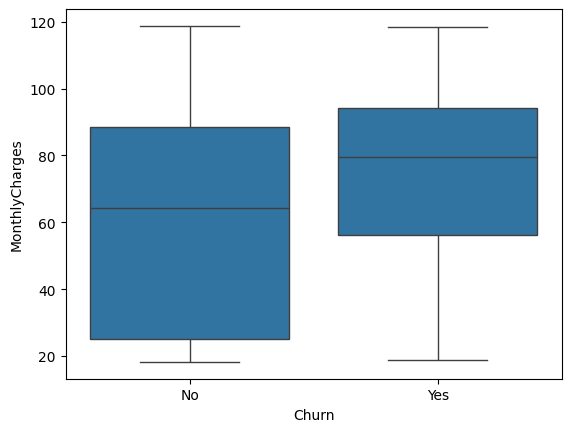

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()


In [12]:
df.groupby("Churn")["tenure"].describe()



,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


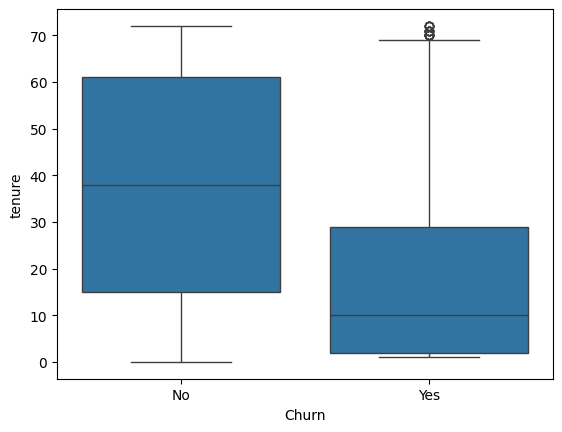

In [13]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.show()


In [14]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [15]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)


In [16]:

X = df.drop(
    columns=['Churn', 'customerID', 'gender'],
    errors='ignore'
)


In [17]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


X = df.drop(columns=['Churn'])
y = df['Churn']


In [18]:
X_encoded = pd.get_dummies(X, drop_first=True)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]


c:\Users\User\Downloads\pimp-your-portfolio\01-churn-prediction-telecom\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [21]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.85      0.88      0.86      1035
           1       0.62      0.57      0.60       374

    accuracy                           0.79      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.79      0.79      1409

ROC-AUC: 0.8357332919992767


In [22]:
import numpy as np

y_pred_03 = (y_proba >= 0.3).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_03))


              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1035
           1       0.52      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.76      1409



In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=10000,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [24]:
y_proba = model.predict_proba(X_test)[:, 1]
threshold = 0.5
y_pred = (y_proba >= threshold).astype(int)


In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.89      0.75      0.82      1035
           1       0.53      0.75      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.80      0.75      0.77      1409



In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\User\AppData\Local\Temp\ipykernel_23156\1521403838.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate_ptr = df.groupby('ptr_bin')['Churn'].apply(lambda x: (x == 'Yes').mean())


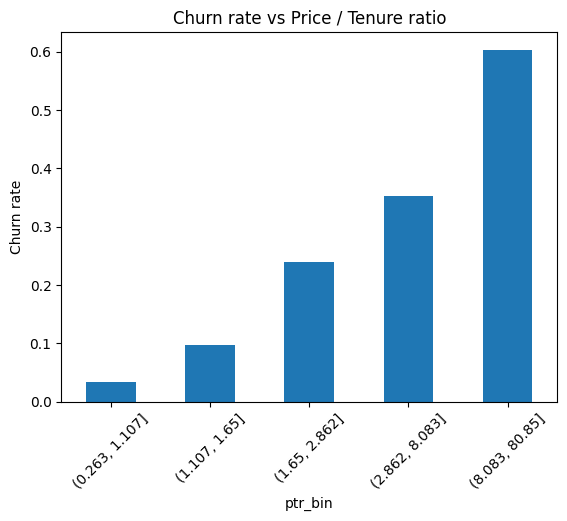

In [8]:


df['price_tenure_ratio'] = df['MonthlyCharges'] / (df['tenure'] + 1)


df['ptr_bin'] = pd.qcut(df['price_tenure_ratio'], q=5)

churn_rate_ptr = df.groupby('ptr_bin')['Churn'].apply(lambda x: (x == 'Yes').mean())

churn_rate_ptr.plot(kind='bar')
plt.ylabel('Churn rate')
plt.title('Churn rate vs Price / Tenure ratio')
plt.xticks(rotation=45)
plt.show()


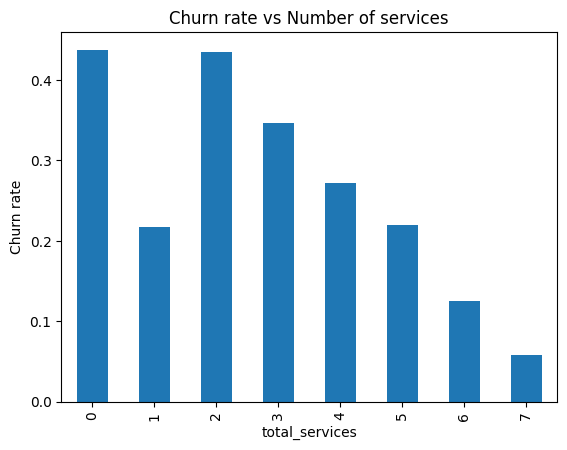

In [9]:
service_cols = [
    'PhoneService', 'InternetService', 'OnlineSecurity',
    'OnlineBackup', 'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies'
]

df['total_services'] = (df[service_cols] == 'Yes').sum(axis=1)



churn_rate_services = df.groupby('total_services')['Churn'].apply(lambda x: (x == 'Yes').mean())

churn_rate_services.plot(kind='bar')
plt.ylabel('Churn rate')
plt.title('Churn rate vs Number of services')
plt.show()



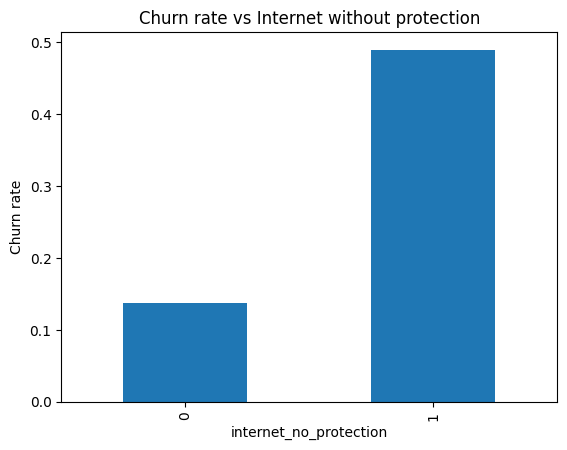

In [10]:
df['internet_no_protection'] = (
    (df['InternetService'] != 'No') &
    (df['OnlineSecurity'] == 'No') &
    (df['TechSupport'] == 'No')
).astype(int)


churn_rate_inp = df.groupby('internet_no_protection')['Churn'].apply(lambda x: (x == 'Yes').mean())

churn_rate_inp.plot(kind='bar')
plt.ylabel('Churn rate')
plt.title('Churn rate vs Internet without protection')
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_23156\4083054220.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate_tenure = df.groupby('tenure_segment')['Churn'].apply(lambda x: (x == 'Yes').mean())


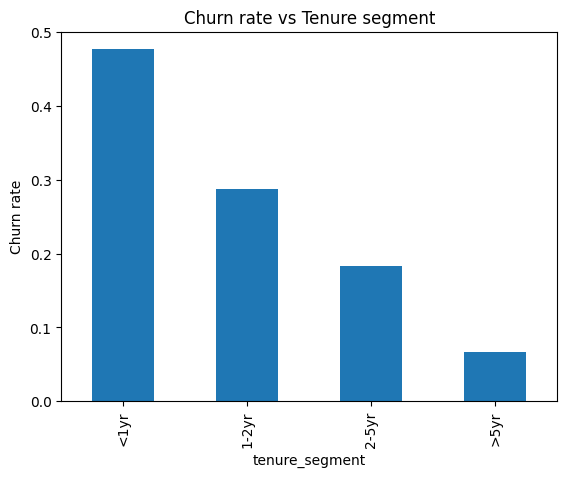

In [11]:
df['tenure_segment'] = pd.cut(
    df['tenure'],
    bins=[0, 12, 24, 60, 100],
    labels=['<1yr', '1-2yr', '2-5yr', '>5yr']
)


churn_rate_tenure = df.groupby('tenure_segment')['Churn'].apply(lambda x: (x == 'Yes').mean())

churn_rate_tenure.plot(kind='bar')
plt.ylabel('Churn rate')
plt.title('Churn rate vs Tenure segment')
plt.show()


In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score

from xgboost import XGBClassifier


In [33]:
DATA_FILE = "telco_churn.csv"
TARGET_COL = "Churn"

# Features
NUMERICAL_FEATURES = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

CATEGORICAL_FEATURES = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [34]:
# Model
MODEL_NAME = "xgboost_churn"
MODEL_VERSION = "1.0.0"
RANDOM_STATE = 42
TEST_SIZE = 0.2

# XGBoost hyperparameters
XGBOOST_PARAMS = {
    "max_depth": 6,
    "learning_rate": 0.1,
    "n_estimators": 200,
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "scale_pos_weight": 3,  # Gestion déséquilibre (73.5/26.5)
    "random_state": RANDOM_STATE,
}

# Thresholds
CHURN_THRESHOLD = 0.5  # Probabilité seuil pour prédire churn
HIGH_RISK_THRESHOLD = 0.7  # Seuil pour risque élevé

# MLflow
MLFLOW_TRACKING_URI = "./mlruns"
EXPERIMENT_NAME = "churn_prediction"

# API
API_TITLE = "Churn Prediction API"
API_VERSION = "1.0.0"
API_HOST = "0.0.0.0"
API_PORT = 8000

In [35]:
df = pd.read_csv("telco_churn.csv")
# Nettoyage TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Remplacer les NaN (clients très récents, tenure = 0)
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Target en binaire
df[TARGET_COL] = df[TARGET_COL].map({"Yes": 1, "No": 0})


In [36]:
X = df[NUMERICAL_FEATURES + CATEGORICAL_FEATURES]
y = df[TARGET_COL]


In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)


In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", NUMERICAL_FEATURES),
        ("cat", OneHotEncoder(
            drop="first",
            handle_unknown="ignore"
        ), CATEGORICAL_FEATURES)
    ]
)


In [39]:
xgb_model = XGBClassifier(
    max_depth=6,
    learning_rate=0.1,
    n_estimators=200,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=3,
    random_state=RANDOM_STATE,
    use_label_encoder=False
)


In [40]:
pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", xgb_model)
])


In [41]:
pipeline.fit(X_train, y_train)


c:\Users\User\Downloads\pimp-your-portfolio\01-churn-prediction-telecom\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [22:32:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [42]:
y_proba = pipeline.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= CHURN_THRESHOLD).astype(int)


In [43]:
print(classification_report(y_test, y_pred))
print("AUC ROC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.88      0.76      0.82      1035
           1       0.53      0.72      0.61       374

    accuracy                           0.75      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.75      0.76      1409

AUC ROC: 0.8309927923738667


In [44]:
def create_features(df):
    df = df.copy()

    # 1. Ratio prix / ancienneté
    df["price_tenure_ratio"] = df["MonthlyCharges"] / (df["tenure"] + 1)

    # 2. Nombre de services souscrits
    service_cols = [
        "PhoneService", "InternetService", "OnlineSecurity",
        "OnlineBackup", "DeviceProtection", "TechSupport",
        "StreamingTV", "StreamingMovies"
    ]
    df["total_services"] = (df[service_cols] == "Yes").sum(axis=1)

    # 3. Internet sans protection
    df["internet_no_protection"] = (
        (df["InternetService"] != "No") &
        (df["OnlineSecurity"] == "No") &
        (df["TechSupport"] == "No")
    ).astype(int)

    # 4. Segment d’ancienneté
    df["tenure_segment"] = pd.cut(
        df["tenure"],
        bins=[0, 12, 24, 60, 100],
        labels=["<1yr", "1-2yr", "2-5yr", ">5yr"]
    )

   
    return df


In [45]:

df = pd.read_csv("telco_churn.csv")
# Nettoyage
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)
df[TARGET_COL] = df[TARGET_COL].map({"Yes": 1, "No": 0})

# Feature engineering
df = create_features(df)

# Séparation
X = df.drop(columns=[TARGET_COL, "customerID"], errors="ignore")
y = df[TARGET_COL]

# Encodage catégoriel
X = pd.get_dummies(X, drop_first=True)

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)


In [46]:
from xgboost import XGBClassifier

model = XGBClassifier(
    **XGBOOST_PARAMS
)

model.fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= CHURN_THRESHOLD).astype(int)


In [47]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
print("AUC ROC:", roc_auc_score(y_test, y_proba))


              precision    recall  f1-score   support

           0       0.89      0.75      0.81      1035
           1       0.52      0.74      0.61       374

    accuracy                           0.75      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.75      0.76      1409

AUC ROC: 0.8327081557260584


In [48]:
import joblib
from pathlib import Path

# Créer le dossier models s'il n'existe pas
Path("models").mkdir(exist_ok=True)

# Sauvegarder le modèle
joblib.dump(model, "models/xgboost_churn.pkl")


['models/xgboost_churn.pkl']

In [49]:
import streamlit as st
import pandas as pd
import joblib

# ==============================
# Feature Engineering (inline)
# ==============================
def create_features(df):
    df = df.copy()

    df["price_tenure_ratio"] = df["MonthlyCharges"] / (df["tenure"] + 1)

    service_cols = [
        "PhoneService", "InternetService", "OnlineSecurity",
        "OnlineBackup", "DeviceProtection", "TechSupport",
        "StreamingTV", "StreamingMovies"
    ]
    df["total_services"] = (df[service_cols] == "Yes").sum(axis=1)

    df["internet_no_protection"] = (
        (df["InternetService"] != "No") &
        (df["OnlineSecurity"] == "No") &
        (df["TechSupport"] == "No")
    ).astype(int)

    df["tenure_segment"] = pd.cut(
        df["tenure"],
        bins=[0, 12, 24, 60, 100],
        labels=["<1yr", "1-2yr", "2-5yr", ">5yr"]
    )

    df["senior_with_dependents"] = (
        (df["SeniorCitizen"] == 1) &
        (df["Dependents"] == "Yes")
    ).astype(int)

    return df


# ==============================
# Charger le modèle
# ==============================
model = joblib.load("models/xgboost_churn.pkl")

st.set_page_config(page_title="Churn Prediction", layout="centered")
st.title("📉 Telco Churn Prediction")

# ==============================
# Inputs utilisateur
# ==============================
tenure = st.slider("Ancienneté (mois)", 0, 72, 12)
monthly = st.slider("Monthly Charges", 18, 120, 70)
total = st.number_input("Total Charges", value=0.0)

contract = st.selectbox("Contract", ["Month-to-month", "One year", "Two year"])
internet = st.selectbox("Internet Service", ["DSL", "Fiber optic", "No"])
security = st.selectbox("Online Security", ["Yes", "No"])
support = st.selectbox("Tech Support", ["Yes", "No"])
payment = st.selectbox(
    "Payment Method",
    ["Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"]
)

# ==============================
# DataFrame client
# ==============================
input_df = pd.DataFrame([{
    "tenure": tenure,
    "MonthlyCharges": monthly,
    "TotalCharges": total,
    "Contract": contract,
    "InternetService": internet,
    "OnlineSecurity": security,
    "TechSupport": support,
    "PaymentMethod": payment,
    "SeniorCitizen": 0,
    "Partner": "No",
    "Dependents": "No",
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "StreamingTV": "No",
    "StreamingMovies": "No",
    "PaperlessBilling": "Yes",
}])

# ==============================
# Prédiction
# ==============================
if st.button("🔍 Prédire le churn"):
    input_df = create_features(input_df)
    input_df = pd.get_dummies(input_df)
    input_df = input_df.reindex(columns=model.feature_names_in_, fill_value=0)

    proba = model.predict_proba(input_df)[0][1]

    st.metric("Probabilité de churn", f"{proba:.2%}")

    if proba >= 0.7:
        st.error("🚨 Risque ÉLEVÉ de churn")
    elif proba >= 0.5:
        st.warning("⚠️ Risque MODÉRÉ")
    else:
        st.success("✅ Client fidèle")


2026-01-31 22:32:23.368 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-31 22:32:23.375 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-31 22:32:25.616 
  command:

    streamlit run c:\Users\User\Downloads\pimp-your-portfolio\01-churn-prediction-telecom\venv\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-01-31 22:32:25.618 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-31 22:32:25.620 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-31 22:32:25.622 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-01-31 22:32:25.625 Thread 'MainThread': missing Scr